In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import stats

# Load the image
image = cv2.imread('pout.tif', cv2.IMREAD_GRAYSCALE)

print(f"Image shape: {image.shape}")
print(f"Image data type: {image.dtype}")
print(f"Pixel value range: [{image.min()}, {image.max()}]")

Image shape: (291, 240)
Image data type: uint8
Pixel value range: [74, 224]


### Implement Histogram Equalization

In [3]:
def histogram_equalization(img):
    
    rows, cols = img.shape
    total_pixels = rows * cols
    
    # Step 1: Calculate histogram (frequency of each intensity level 0-255)
    hist = np.zeros(256, dtype=np.int32)
    for i in range(rows):
        for j in range(cols):
            pixel_value = img[i, j]
            hist[pixel_value] += 1
    
    # Calculate probability of each intensity level
    prob = hist / total_pixels
    
    # Calculate Cumulative Distribution Function (CDF)
    cdf = np.zeros(256, dtype=np.float32)
    cdf[0] = prob[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + prob[i]
    
    # Create mapping function (CDF * 255)
    # Round to nearest integer for discrete intensity values
    mapping = np.round(cdf * 255).astype(np.uint8)
    
    # Apply mapping to each pixel
    equalized_img = np.zeros_like(img)
    for i in range(rows):
        for j in range(cols):
            equalized_img[i, j] = mapping[img[i, j]]
    
    return equalized_img, cdf, hist, mapping

# Apply histogram equalization
equalized_image, cdf, original_hist, mapping = histogram_equalization(image)

### Calculate histogram of equalized image

In [4]:

equalized_hist = np.zeros(256, dtype=np.int32)
rows, cols = equalized_image.shape
for i in range(rows):
    for j in range(cols):
        equalized_hist[equalized_image[i, j]] += 1

### Create the 4-Panel Subplot Visualization

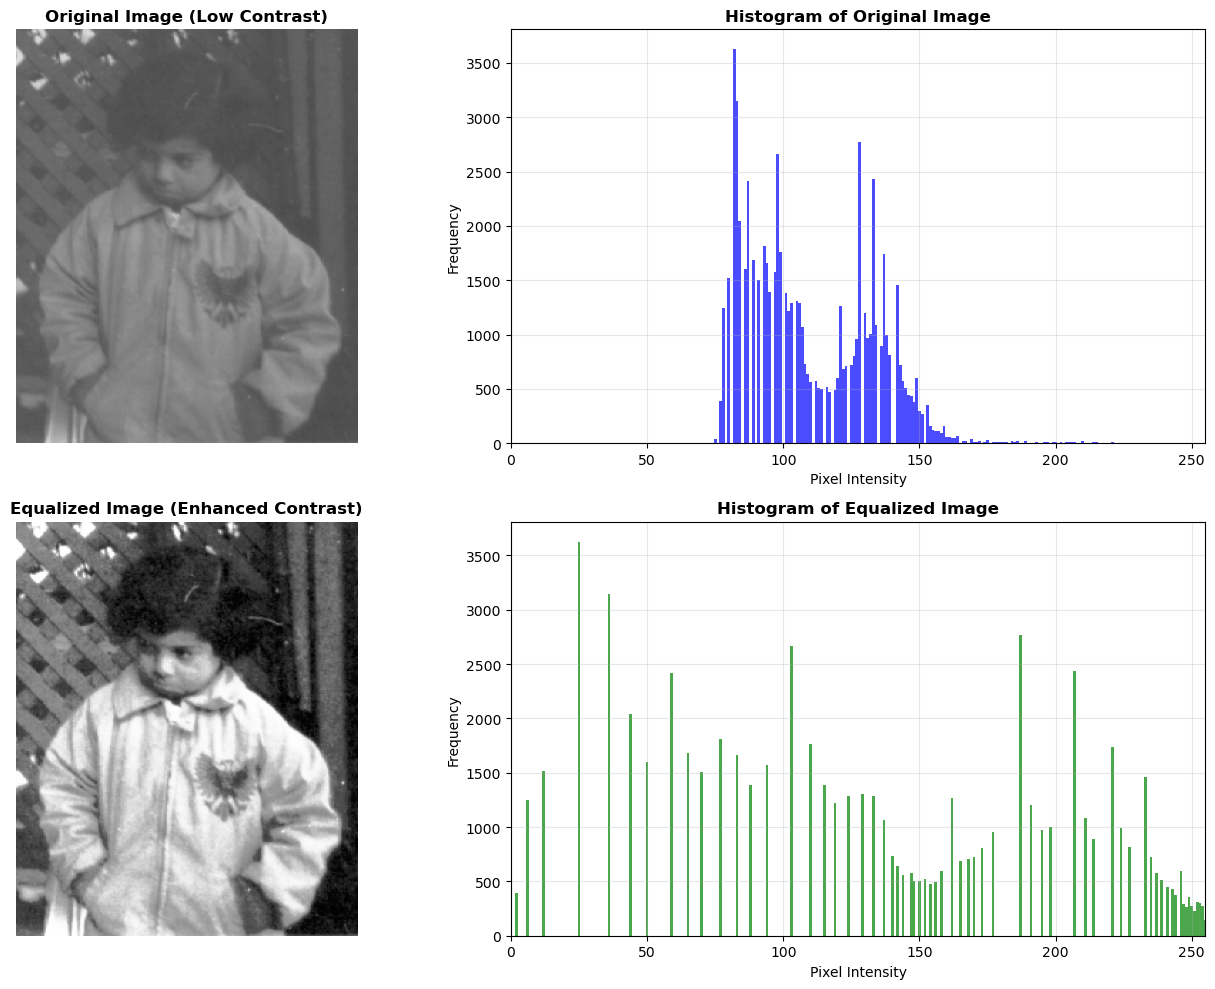

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Original Image
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image (Low Contrast)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Plot 2: Histogram of Original Image
axes[0, 1].bar(np.arange(256), original_hist, width=1.0, color='blue', alpha=0.7)
axes[0, 1].set_title('Histogram of Original Image', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Pixel Intensity', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_xlim([0, 255])
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Equalized Image
axes[1, 0].imshow(equalized_image, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Equalized Image (Enhanced Contrast)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Plot 4: Histogram of Equalized Image
axes[1, 1].bar(np.arange(256), equalized_hist, width=1.0, color='green', alpha=0.7)
axes[1, 1].set_title('Histogram of Equalized Image', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Pixel Intensity', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histogram_equalization_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Theoretical Analysis: Why Isn't the Equalized Histogram Perfectly Uniform?

1. **Discrete Intensity Levels (Quantization):**
   - Digital images have only 256 discrete gray levels (0-255)
   - The CDF is a discrete function, not a continuous one
   - The mapping s_k = round((L-1) * CDF(r_k)) creates quantization errors
   - Multiple input intensities may map to the same output intensity, causing spikes

2. **Limited Number of Pixels:**
   - For a perfectly uniform histogram, each intensity level should have exactly total_pixels/256 pixels
   - With a 256×256 image (65,536 pixels), each level should have exactly 256 pixels
   - In practice, this exact division is impossible due to integer constraints

3. **Rounding Errors:**
   - The mapping function uses rounding: s = round(CDF(r) × 255)
   - This creates gaps where no input intensities map to certain output levels
   - Some output intensities may receive pixels from multiple input levels

4. **Original Histogram Gaps:**
   - If the original histogram has zero frequencies, the CDF remains constant over those ranges
   - When mapping, these constant regions cause "jumps" in the output histogram

**Why Gaps and Spikes Appear:**
- **Gaps (zero frequencies):** When no input intensity maps to a specific output level due to rounding
- **Spikes (high frequencies):** When multiple input intensities with high original frequencies map to the same output level

The resulting histogram approximates uniformity but remains discrete and imperfect. This is an inherent limitation of digital image processing—the "information bottleneck" caused by quantization prevents achieving true mathematical uniformity.